In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ads_data = pd.read_csv('ad_perf_data.csv')

In [189]:
# ads_data

**Online Advertising Performance Data**

The dataset provides insights into the online advertising performance of a company, referred to as "Company X", from April 1, 2020, to June 30, 2020. The currency used for transactions is the US dollar.

**Metrics:**

- **Day**: Date of the advertising campaign.
- **Campaign**: A segmentation variable set by Company X to target specific groups of users with advertisements.
- **User Engagement**: Indicates the level of engagement of users targeted by the advertising campaign.
- **Banner**: Represents the size of the ad served by an advertising platform, referred to as "Advert Firm A".

- **Placement**: Denotes the publisher space where the ad is served by "Advert Firm A", such as websites or apps.
- **Displays**: The number of ads served by "Advert Firm A" during the campaign period.
- **Cost**: The price paid by "Advert Firm A" to serve the ads to the publisher. It reflects the placement cost of the advertisements.
- **Clicks**: The number of times users clicked on the advertisements during the campaign.
- **Revenue**: The price paid by Company X to "Advert Firm A" for the clicks generated through the advertising campaign.
- **Post Click Conversions**: Represents on-site transactions that occurred within the next 30 days after a user clicked on the advertisement.
- **Post Click Sales Amount**: The monetary value of on-site transactions that occurred within the next 30 days after a user clicked on the advertisement.

Additional Information:

- **Engagement**: This variable signifies the type of users targeted by the campaign based on their behavior or characteristics.
  
- **Banner**: Defines the size of the advertisement or impression served to users.

- **Placement**: Specifies the website or app where the advertisement is being served, without disclosing the specific names of publishers.

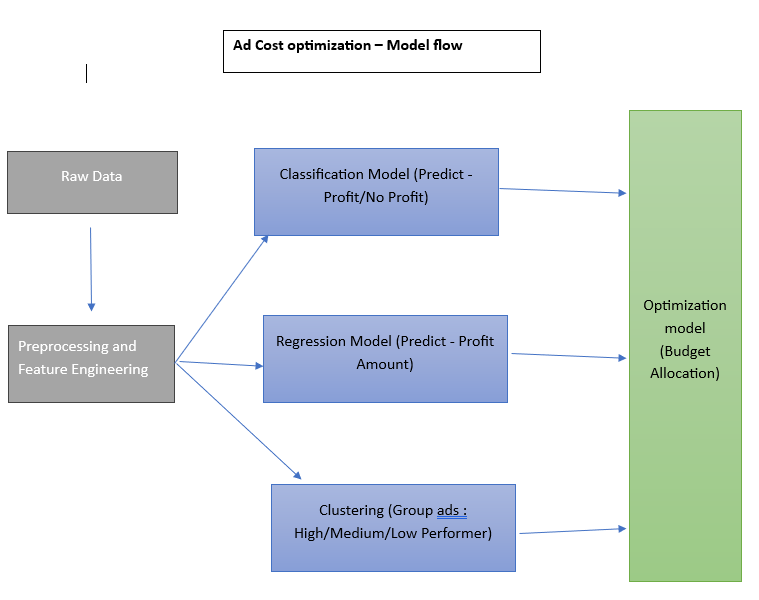

# EDA

Reading from CSV file
- It has 2 Unmaed Columns

In [190]:
# ads_data.info()

In [191]:
# ads_data.describe(include='all')

Reading the xlsx data
- This does not have junk column data

In [192]:
ads_data_xl = pd.read_excel('online_advertising_performance_data.xlsx')
ads_data_xl.head(10)

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000
5,April,1,camp 1,Low,160 x 600,ghi,16,0.0249,0,0.0000,0,0.0000
6,April,1,camp 1,Low,160 x 600,mno,2234,0.4044,10,1.8347,3,101.7494
7,April,1,camp 1,Medium,160 x 600,def,2963,1.8899,4,0.7338,4,100.5044
8,April,1,camp 1,Medium,160 x 600,ghi,580,0.9917,9,1.6512,0,0.0000
9,April,1,camp 1,Medium,160 x 600,mno,20152,11.1678,185,33.9397,13,653.1896


**Step 1** : Descriptive EDA – Structural Analysis

In [193]:
ads_data_xl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15408 entries, 0 to 15407
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    15408 non-null  object 
 1   day                      15408 non-null  int64  
 2   campaign_number          15408 non-null  object 
 3   user_engagement          15408 non-null  object 
 4   banner                   15408 non-null  object 
 5   placement                14995 non-null  object 
 6   displays                 15408 non-null  int64  
 7   cost                     15408 non-null  float64
 8   clicks                   15408 non-null  int64  
 9   revenue                  15408 non-null  float64
 10  post_click_conversions   15408 non-null  int64  
 11  post_click_sales_amount  15408 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


**Findings**
- Total 12 columns
- 15408 rows in the file
- 3 different data types (float, int, objects)
- Placement column does have some null values
- 5 objects coulumn that need to be reviewed

In [194]:
# Checking for missing values for placement feature
null_values = ads_data_xl['placement'].isnull().sum()
datset_size = len(ads_data_xl)
null_values_percentage = (null_values / datset_size) * 100
print(f"Number of null values: {null_values}")
print(f"Percentage of null values: {null_values_percentage:.2f}%")

Number of null values: 413
Percentage of null values: 2.68%


In [195]:
# Dropping the null values as null values < 5 % of total volume number of records
ads_data_xl.dropna(subset='placement', inplace=True)
ads_data_xl['placement'].isnull().sum()

np.int64(0)

In [196]:
ads_data_xl.describe()

,day,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount
count,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000
mean,15.471957,15939.616939,11.683242,166.244215,18.423759,43.465555,2181.756135
std,8.741317,44923.954378,45.950340,737.736875,98.059296,216.491678,10660.989934
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,102.000000,0.030200,0.000000,0.000000,0.000000,0.000000
50%,15.000000,1336.000000,0.377500,7.000000,0.542300,0.000000,0.000000
75%,23.000000,9619.000000,2.705250,57.000000,4.000000,3.000000,185.275250
max,31.000000,455986.000000,556.704800,14566.000000,2096.211600,3369.000000,199930.318000


Findings
- day is not individually an insightful column
- display has huge std deviation
- cost has huge std deviation
- clicks has huge std deviation
- post_click_conversations has huge std deviation
- post_click_sales_amount has huge std deviation

In [197]:
# Checking for Duplicate Values
duplicate_rows = ads_data_xl[ads_data_xl.duplicated()]
display(duplicate_rows)

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount
15403,April,1,camp 1,Low,160 x 600,ghi,16,0.0249,0,0.0000,0,0.0000
15404,April,1,camp 1,Low,160 x 600,mno,2234,0.4044,10,1.8347,3,101.7494
15405,June,29,camp 1,High,800 x 250,ghi,1,0.0157,0,0.0000,0,0.0000
15406,June,29,camp 1,High,800 x 250,mno,4,0.0123,0,0.0000,0,0.0000
15407,June,29,camp 3,High,240 x 400,def,1209,0.3184,2,0.1115,3,110.4224


I do not see the records are truly duplicate as
- Combination of month, day, campaign_number, user_enagement, banner and placement.
- Also it does make sense to keep these records to track the clicks for unique placement on a day

Creating new Features
- By detault target column is not provided
- Based on the problem statement the objective is to maximize the ROI so target feature i.e ROI has to be calculated from provided columns
- Apart from ROI, Other derived feature or Marketing KPI would be
  - Click per Display (CTR)
  - Cost per Click (CPC)


In [198]:
# Handle the devide by zero exception
ads_data_xl['ctr'] = np.where((ads_data_xl['displays']!= 0), (ads_data_xl['clicks']/ads_data_xl['displays']), 0)
ads_data_xl['cpc'] = np.where((ads_data_xl['clicks']!= 0), (ads_data_xl['cost']/ads_data_xl['clicks']), 0)
ads_data_xl['ROI'] = np.where((ads_data_xl['cost']!=0), ((ads_data_xl['revenue']-ads_data_xl['cost'])/ads_data_xl['cost']), 0)

In [199]:
# re validating the data type and non-null
ads_data_xl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14995 entries, 0 to 15407
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    14995 non-null  object 
 1   day                      14995 non-null  int64  
 2   campaign_number          14995 non-null  object 
 3   user_engagement          14995 non-null  object 
 4   banner                   14995 non-null  object 
 5   placement                14995 non-null  object 
 6   displays                 14995 non-null  int64  
 7   cost                     14995 non-null  float64
 8   clicks                   14995 non-null  int64  
 9   revenue                  14995 non-null  float64
 10  post_click_conversions   14995 non-null  int64  
 11  post_click_sales_amount  14995 non-null  float64
 12  ctr                      14995 non-null  float64
 13  cpc                      14995 non-null  float64
 14  ROI                      14

In [200]:
# Descriptive analysis for just 3 new features
ads_data_xl[["ctr", "cpc", "ROI"]].describe()

,ctr,cpc,ROI
count,14995.000000,14995.000000,14995.000000
mean,0.008242,0.057263,0.964878
std,0.031651,0.079717,9.648266
min,0.000000,0.000000,-1.000000
25%,0.000000,0.000000,-1.000000
50%,0.003793,0.026529,-0.085564
75%,0.008772,0.082877,1.271028
max,1.393939,1.241500,537.000000


Findings from the enginnered Feature columns
- ROI has negative value which means many placements are not profitable
- Std deviation is not close to range (max-min) value, so it shows outliers


In [201]:
num_columns = ads_data_xl.select_dtypes(include=['int64', 'float64'])
num_columns.drop(columns='day', inplace=True)

# Descriptive analysis before removing outliers
num_columns.describe()


,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,ctr,cpc,ROI
count,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000
mean,15939.616939,11.683242,166.244215,18.423759,43.465555,2181.756135,0.008242,0.057263,0.964878
std,44923.954378,45.950340,737.736875,98.059296,216.491678,10660.989934,0.031651,0.079717,9.648266
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,102.000000,0.030200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
50%,1336.000000,0.377500,7.000000,0.542300,0.000000,0.000000,0.003793,0.026529,-0.085564
75%,9619.000000,2.705250,57.000000,4.000000,3.000000,185.275250,0.008772,0.082877,1.271028
max,455986.000000,556.704800,14566.000000,2096.211600,3369.000000,199930.318000,1.393939,1.241500,537.000000


In [202]:
# for col in num_columns.columns:
#     plt.figure(figsize=(8, 4))
#     sns.histplot(data=ads_data_xl, x=col,bins=30, kde=True, color = 'skyblue')
#     plt.axvline(ads_data_xl[col].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
#     plt.axvline(ads_data_xl[col].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
#     plt.title(f'Distribution of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency (log scale)')
#     plt.yscale('log') # Set y-axis to logarithmic scale
#     plt.show()

In [203]:
# for column in num_columns.columns:
#     sns.boxplot(y=ads_data_xl[column],     boxprops=dict(facecolor='lightblue'), flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none'),
#     whiskerprops=dict(color='gray'),capprops=dict(color='gray'),medianprops=dict(color='black'))
#     # plt.axvline(ads_data_xl[column].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
#     # plt.axvline(ads_data_xl[column].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
#     plt.title(f'Distribution of {column}')
#     plt.ylabel(column)
#     plt.xlabel('Frequency (log scale)')
#     plt.yscale('log')
#     plt.show()

Remove Outliers

In [204]:
for column in num_columns.columns:
    Q1 = num_columns[column].quantile(0.25)
    Q3 = num_columns[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_columns = num_columns[(num_columns[column] >= lower_bound) & (num_columns[column] <= upper_bound)]
    print(f"Number records considered to be outlier from {column} is {num_columns[column].value_counts().sum()}")
# num_columns.describe()

Number records considered to be outlier from displays is 12861
Number records considered to be outlier from cost is 11029
Number records considered to be outlier from clicks is 9788
Number records considered to be outlier from revenue is 9005
Number records considered to be outlier from post_click_conversions is 7995
Number records considered to be outlier from post_click_sales_amount is 7987
Number records considered to be outlier from ctr is 7108
Number records considered to be outlier from cpc is 6185
Number records considered to be outlier from ROI is 5315


We are not removing the outlier data as :
- About 20% data across the feature has outlier, which is quite significant
- All the outliers are for high return campaigns, and we can not remove them as the model should identify the trend for such campaigns

In [205]:
# for column in num_columns.columns:
#     sns.boxplot(y=ads_data_xl[column],     boxprops=dict(facecolor='lightblue'),
#     flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none'),
#     whiskerprops=dict(color='gray'),
#     capprops=dict(color='gray'),
#     medianprops=dict(color='black'))
#     # plt.axvline(ads_data_xl[column].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
#     # plt.axvline(ads_data_xl[column].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
#     plt.title(f'Distribution of {column}')
#     plt.ylabel(column)
#     plt.xlabel('Frequency (log scale)')
#     plt.yscale('log')
#     plt.show()

In [206]:
# # After Outlier removal
# num_columns.describe()

In [207]:
# Checking correlation of a feature to target variable
# ads_data_xl.corr()

Data Analysis for Categorical column

In [208]:
ads_data_xl.describe(include='object')

,month,campaign_number,user_engagement,banner,placement
count,14995,14995,14995,14995,14995
unique,3,3,3,8,5
top,April,camp 3,Medium,300 x 250,mno
freq,6076,6720,5327,2808,4501


In [209]:
ads_data_xl.head(10)

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,ctr,cpc,ROI
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000,0.000000,0.000000,-1.000000
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602,0.007833,0.169509,0.081744
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636,0.010748,0.174876,0.048740
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234,0.010487,0.120754,0.519086
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000,0.001812,0.067000,1.737313
5,April,1,camp 1,Low,160 x 600,ghi,16,0.0249,0,0.0000,0,0.0000,0.000000,0.000000,-1.000000
6,April,1,camp 1,Low,160 x 600,mno,2234,0.4044,10,1.8347,3,101.7494,0.004476,0.040440,3.536845
7,April,1,camp 1,Medium,160 x 600,def,2963,1.8899,4,0.7338,4,100.5044,0.001350,0.472475,-0.611725
8,April,1,camp 1,Medium,160 x 600,ghi,580,0.9917,9,1.6512,0,0.0000,0.015517,0.110189,0.665020
9,April,1,camp 1,Medium,160 x 600,mno,20152,11.1678,185,33.9397,13,653.1896,0.009180,0.060366,2.039068


Encoding for categorical columns
- month,campaign_number, banner and placement is suitable for One-hot encoding as these are nonordinal features
- user_engagement should be label encoded as it is ordinal

In [210]:
# categorical_cols = ads_data_xl.select_dtypes(include='object').columns.tolist()
from sklearn.preprocessing import LabelEncoder as le

ads_data_oh_encoded=pd.get_dummies(ads_data_xl, columns=['month','campaign_number', 'banner', 'placement'])
ads_data_oh_encoded.head(5)


ads_data_le_encoded = le().fit_transform(ads_data_xl['user_engagement'])
ads_data_encoded = ads_data_oh_encoded.drop(columns='user_engagement')
ads_data_encoded['user_engagement'] = ads_data_le_encoded
ads_data_encoded.head(5)

,day,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,ctr,cpc,ROI,...,banner_580 x 400,banner_670 x 90,banner_728 x 90,banner_800 x 250,placement_abc,placement_def,placement_ghi,placement_jkl,placement_mno,user_engagement
0,1,4,0.0060,0,0.0000,0,0.0000,0.000000,0.000000,-1.000000,...,False,False,False,False,True,False,False,False,False,0
1,1,20170,26.7824,158,28.9717,23,1972.4602,0.007833,0.169509,0.081744,...,False,False,False,False,False,True,False,False,False,0
2,1,14701,27.6304,158,28.9771,78,2497.2636,0.010748,0.174876,0.048740,...,False,False,False,False,False,False,True,False,False,0
3,1,171259,216.8750,1796,329.4518,617,24625.3234,0.010487,0.120754,0.519086,...,False,False,False,False,False,False,False,False,True,0
4,1,552,0.0670,1,0.1834,0,0.0000,0.001812,0.067000,1.737313,...,False,False,False,False,False,True,False,False,False,1


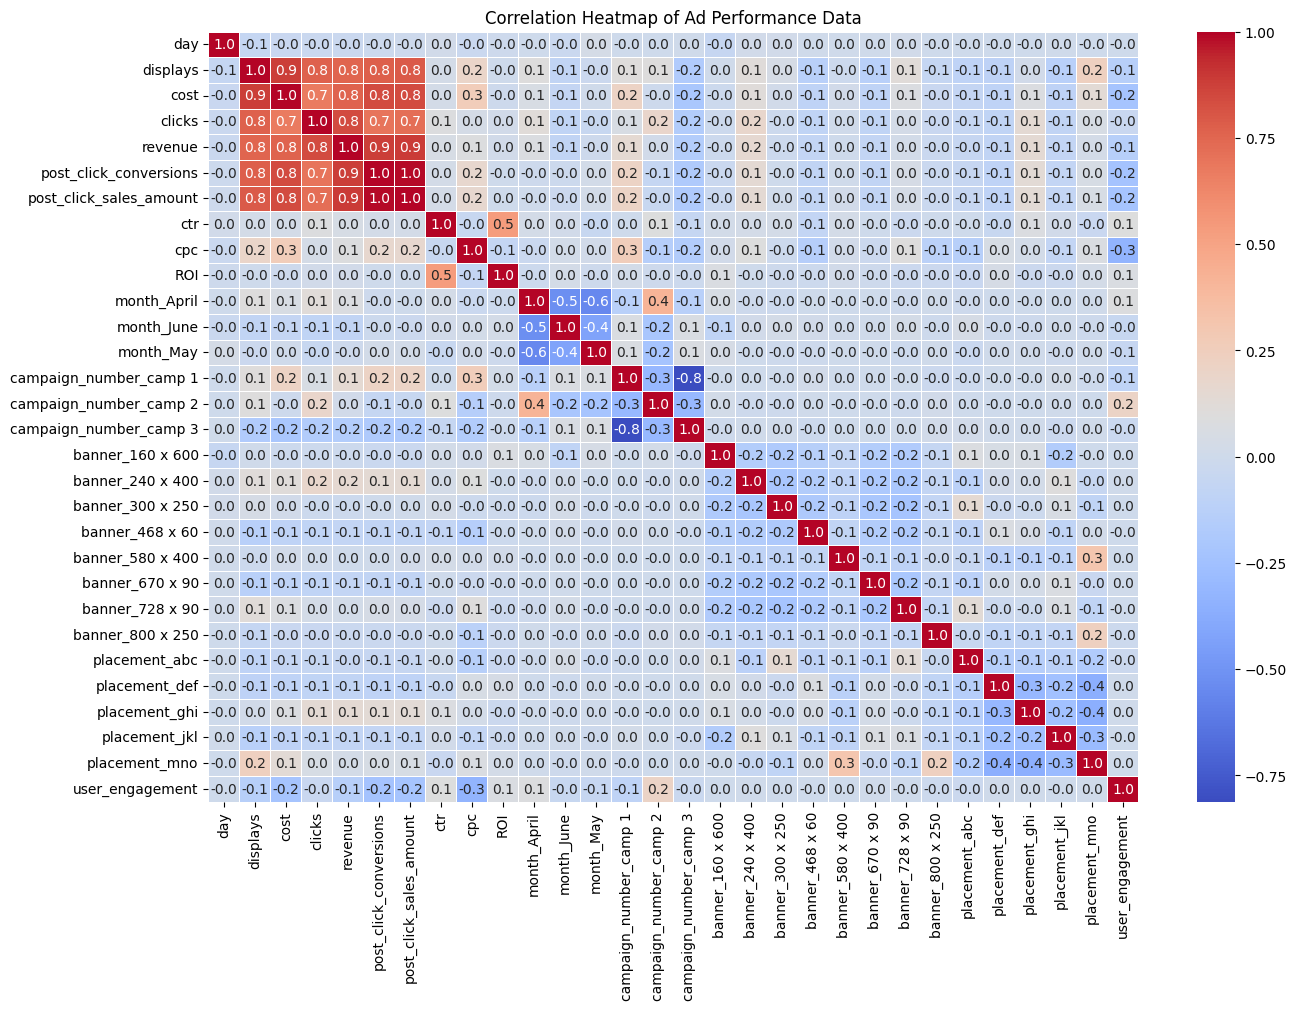

In [211]:
plt.figure(figsize=(15, 10))
sns.heatmap(ads_data_encoded.corr(), annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.title('Correlation Heatmap of Ad Performance Data')
plt.show()

# Model Selection
- We have 2 high level option
  - Linear regression
  - Classification model
- We are choosing classification model as:
  - The problem statement say to build a strategy to predict profit
  - The continous value feature i.e ROI is higly skewed
  - Standard deviation shows non-linear relation

In [212]:
ads_data_encoded.head(5)

,day,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,ctr,cpc,ROI,...,banner_580 x 400,banner_670 x 90,banner_728 x 90,banner_800 x 250,placement_abc,placement_def,placement_ghi,placement_jkl,placement_mno,user_engagement
0,1,4,0.0060,0,0.0000,0,0.0000,0.000000,0.000000,-1.000000,...,False,False,False,False,True,False,False,False,False,0
1,1,20170,26.7824,158,28.9717,23,1972.4602,0.007833,0.169509,0.081744,...,False,False,False,False,False,True,False,False,False,0
2,1,14701,27.6304,158,28.9771,78,2497.2636,0.010748,0.174876,0.048740,...,False,False,False,False,False,False,True,False,False,0
3,1,171259,216.8750,1796,329.4518,617,24625.3234,0.010487,0.120754,0.519086,...,False,False,False,False,False,False,False,False,True,0
4,1,552,0.0670,1,0.1834,0,0.0000,0.001812,0.067000,1.737313,...,False,False,False,False,False,True,False,False,False,1


# Classification Model building - Without Scaling


In [213]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


ads_data_encoded["is_profitable"] = ads_data_encoded["ROI"].apply(lambda x: 1 if x > 0 else 0)

# Addressing the data leakage (The process of providing a cheat sheet to a
# model while training and it can not do a better prediction with real data) by dropping ROI feature
x = ads_data_encoded.drop(columns=["ROI", "is_profitable", "day"])
y = ads_data_encoded["is_profitable"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# logistic regression model
classifier = LogisticRegression(max_iter=10000, random_state=42)
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(report)
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1611
           1       0.99      0.94      0.97      1388

    accuracy                           0.97      2999
   macro avg       0.97      0.97      0.97      2999
weighted avg       0.97      0.97      0.97      2999

[[1602    9]
 [  83 1305]]


# Model 1 (Predict Profit or No Profit): Classification Model building - With Scaling

Given that the some of the feature has value in the range of thoushands (post_click_sale_amount, display) whereas some feature has values in decimal (CTR, CP, ROI) so scaling is needed here

In [214]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()

# 2 methods used here
# 1st fit_transform -
# 2nd transform -
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train the logistic regression model with scaled data
classifier_scaled = LogisticRegression(max_iter=1000, random_state=42)
classifier_scaled.fit(x_train_scaled, y_train)

# Make predictions with the scaled data
y_pred_scaled = classifier_scaled.predict(x_test_scaled)

report = classification_report(y_test, y_pred_scaled)
conf_matrix = confusion_matrix(y_test, y_pred_scaled)
print(report)
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1611
           1       0.90      0.91      0.90      1388

    accuracy                           0.91      2999
   macro avg       0.91      0.91      0.91      2999
weighted avg       0.91      0.91      0.91      2999

[[1475  136]
 [ 130 1258]]


In [215]:
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(x_train, y_train)

y_pred_rf = random_forest_classifier.predict(x_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1611
           1       0.99      0.99      0.99      1388

    accuracy                           0.99      2999
   macro avg       0.99      0.99      0.99      2999
weighted avg       0.99      0.99      0.99      2999

[[1600   11]
 [  10 1378]]


The Random Forest Classifier significantly outperforms the Logistic Regression model based on all metrics (precision, recall, f1-score, and accuracy).

- Accuracy: Random Forest has a much higher overall accuracy (0.99) compared to Logistic Regression (0.91).
- Precision and Recall: Random Forest shows very high precision and recall for both classes (0 and 1), indicating that it is much better at correctly identifying both profitable (1) and non-profitable (0) instances with fewer false positives and false negatives. Logistic Regression has lower precision and recall for both classes, with a notable number of false positives (136) and false negatives (130).
- F1-score: The f1-score, which is the harmonic mean of precision and recall, is also much higher for Random Forest (0.99) compared to Logistic Regression (0.90 and 0.91), confirming its superior performance in balancing precision and recall.
- Confusion Matrix: The confusion matrix clearly shows that the Random Forest model makes significantly fewer errors in classification (only 11 false positives and 10 false negatives) compared to the Logistic Regression model (136 false positives and 130 false negatives).

# Model 2 (Predit profit amount) - Regression Model

In [216]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("--- Linear Regression Model (with scaling) ---")

# Define the target variable as 'ROI'
y_regression = ads_data_encoded['ROI']

# Select features (excluding 'ROI', 'is_profitable', and 'day')
x_regression = ads_data_encoded.drop(columns=["ROI", "is_profitable", "day"])

# Split the data into training and testing sets
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_regression, y_regression, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
x_train_reg_scaled = scaler.fit_transform(x_train_reg)
x_test_reg_scaled = scaler.transform(x_test_reg)


# Choose and train a Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(x_train_reg_scaled, y_train_reg)

# Make predictions on the test data
y_pred_reg = linear_reg_model.predict(x_test_reg_scaled)

# Evaluate the model
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Linear Regression Model (with scaling) ---
Linear Regression Model Performance:
Mean Squared Error (MSE): 24.91
Root Mean Squared Error (RMSE): 4.99
R-squared (R2): 0.05


In [217]:
from sklearn.ensemble import RandomForestRegressor

print("--- Random Forest Regressor Model (with scaling) ---")

# Define the target variable as 'ROI'
y_regression = ads_data_encoded['ROI']

# Select features (excluding 'ROI', 'is_profitable', and 'day')
x_regression = ads_data_encoded.drop(columns=["ROI", "is_profitable", "day"])

# Split the data into training and testing sets
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_regression, y_regression, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
x_train_reg_scaled = scaler.fit_transform(x_train_reg)
x_test_reg_scaled = scaler.transform(x_test_reg)

# Choose and train a RandomForestRegressor model
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(x_train_reg_scaled, y_train_reg)

# Make predictions on the test data
y_pred_rf_reg = rf_reg_model.predict(x_test_reg_scaled)

# Evaluate the model
mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mse_rf) # Calculate RMSE by taking the square root of MSE
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("Random Forest Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

--- Random Forest Regressor Model (with scaling) ---
Random Forest Regressor Model Performance:
Mean Squared Error (MSE): 1.81
Root Mean Squared Error (RMSE): 1.34
R-squared (R2): 0.93


Comparing the results:

Linear Regression Model Performance:

Mean Squared Error (MSE): 24.91
Root Mean Squared Error (RMSE): 4.99
R-squared (R2): 0.05
Random Forest Regressor Model Performance:

Mean Squared Error (MSE): 1.81
Root Mean Squared Error (RMSE): 1.34
R-squared (R2): 0.93
Again, the RandomForestRegressor model significantly outperforms the Linear Regression model in predicting ROI.

In [218]:
y_pred_rf_reg = rf_reg_model.predict(x_test_reg_scaled)
y_pred_reg = linear_reg_model.predict(x_test_reg_scaled)

print("Linear Regression Predictions:")
print(y_pred_reg[:5])

print("\nRandom Forest Regressor Predictions:")
print(y_pred_rf_reg[:5])

print("\nActual Values:")
print(y_test_reg[:5])

Linear Regression Predictions:
[ 0.02601049  1.16597865  1.13188772 -0.73443697  1.89085974]

Random Forest Regressor Predictions:
[ 3.2143536   1.12613462 -1.          0.37720467  0.92409851]

Actual Values:
13764    3.212355
6669     1.115716
10229   -1.000000
862      0.412299
6157     0.984797
Name: ROI, dtype: float64


# Model 3 (Predict Low/Medium/High performing ads) - Clustering

---



In [219]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for clustering (excluding 'day' as it's not performance related)
numerical_features_for_clustering = ads_data_encoded.select_dtypes(include=['int64', 'float64']).drop(columns=['day', 'is_profitable'])

# Add the 'user_engagement' column, which was label encoded
numerical_features_for_clustering['user_engagement'] = ads_data_encoded['user_engagement']


# Scale the features
scaler_clustering = StandardScaler()
scaled_features = scaler_clustering.fit_transform(numerical_features_for_clustering)

print("Scaled features for clustering:")
print(scaled_features[:5])

Scaled features for clustering:
[[-0.3547361  -0.25413591 -0.22535102 -0.18789012 -0.2007791  -0.20465537
  -0.26042072 -0.71834919 -0.20365767 -1.27433787]
 [ 0.09417079  0.32860826 -0.01117538  0.10757055 -0.09453591 -0.0196326
  -0.01291792  1.40810699 -0.09153596 -1.27433787]
 [-0.02757233  0.34706358 -0.01117538  0.10762562  0.1595239   0.02959556
   0.07915696  1.47543609 -0.09495681 -1.27433787]
 [ 3.45749978  4.4656601   2.20920248  3.17194213  2.64931001  2.10527501
   0.07092537  0.7964923  -0.04620587 -1.27433787]
 [-0.3425373  -0.25280834 -0.22399548 -0.18601977 -0.2007791  -0.20465537
  -0.20318201  0.12215297  0.08006221 -0.05044135]]


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the elbow method
wcss = []
# Trying k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # Explicitly set n_init
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
ads_data_xl['cluster_label'] = kmeans.fit_predict(scaled_features)

print("Cluster labels added to the DataFrame:")
display(ads_data_xl.head())

In [ ]:
# Analyze the characteristics of each cluster
# Select only numerical columns from the original dataframe before grouping
numerical_cols_in_original_df = ads_data_xl.select_dtypes(include=np.number).columns.tolist()
cluster_characteristics = ads_data_xl.groupby('cluster_label')[numerical_cols_in_original_df].mean()

print("Cluster Characteristics (Mean Values):")
display(cluster_characteristics)

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ads_data_xl, x='clicks', y='ROI', hue='cluster_label', palette='viridis')
plt.title('Cluster Visualization based on Clicks and ROI')
plt.xlabel('Clicks')
plt.ylabel('ROI')
plt.grid(True)
plt.show()

we can interpret the three clusters as representing different levels of ad performance:

- Cluster 0: This cluster appears to represent Low Performing Ads. They have very low mean values across most performance metrics like displays, cost, clicks, revenue, post-click conversions, and post-click sales amount. Interestingly, they have a very high mean CTR and ROI, but this is likely due to the very low number of displays and costs amplifying the few clicks and minimal revenue/sales. These are likely ads with very limited reach but perhaps high relevance to the few users they reach.
- Cluster 1: This cluster seems to represent Medium Performing Ads. They have moderate mean values for displays, cost, clicks, revenue, and post-click metrics compared to the other clusters. Their average CTR and ROI are lower than Cluster 0 but significantly higher than
- Cluster 2. This cluster likely represents the bulk of the ad campaigns with average reach and performance.
Cluster 2: This cluster likely represents High Performing Ads. They have the highest mean values for displays, cost, clicks, revenue, post-click conversions, and post-click sales amount. While their average CTR and ROI are lower than Cluster 0, the high volume of activity and sales indicates these are the campaigns driving significant results and revenue despite a lower per-click return than the very small-scale high-ROI ads in Cluster 0. These are the campaigns with high reach and substantial conversions/sales.